# Dataset Provenance and Scientific Context

The CRCNS PVC-2 dataset used in this notebook contains extracellular spike recordings from neurons in the **primary visual cortex (V1) of anesthetized cats**, collected in the laboratory of **Yang Dan (UC Berkeley)**. These recordings were used in influential studies on how cortical neurons encode visual stimuli.

Two key publications based on this dataset are:

#### 1. Touryan, Lau & Dan (2002) — *Isolation of relevant visual features from random stimuli for cortical complex cells*  
**Journal of Neuroscience, 22, 10811–10818**

This study used random stimulus ensembles and spike-triggered covariance methods to identify the stimulus features that drive **complex cells** in V1. It demonstrated that nonlinear receptive field components of cortical neurons can be recovered directly from spike responses.

#### 2. Touryan, Felsen & Dan (2005) — *Spatial Structure of Complex Cell Receptive Fields Measured with Natural Images*  
**Neuron, 45, 781–791**

This later work extended the analysis to **natural image stimuli**, showing that complex-cell receptive fields can be described by a small number of oriented subunits. The results supported the classical **energy model** of visual cortical processing and provided an early example of nonlinear neural encoding under naturalistic stimulation.

## structure of the dataset
Based on archived correspondence from the original investigators, filenames encode:

YYMMDD.(chamber).(penetration)(cell number)(run number)(stimulus).(filetype)

Thus files such as `000413.b03bmsq1D.sa0`, `000413.b03cmsq1D.sa0`, and `000413.b03dmsq1D.sa0` correspond to the same recorded unit (`b03`) across different sequential runs (`b`, `c`, `d`) using the `msq1D` stimulus.



# settings for the project

In [1]:
from pathlib import Path
import numpy as np
from scipy.io import loadmat
import os
import matplotlib.pyplot as plt
import sys

In [2]:
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))


DATA_ROOT=PROJECT_ROOT/'data'/'crcns-pvc2'
root =DATA_ROOT / "1D_white_noise/Spike_and_Log_Files"



from src.get_spikes import (fget_spk_python, retrieve_log, tori,
                            load_log_lines, numbers,
                            search_log)

from src.utiles import (is_it_complex, compute_sta, 
                        compute_r_estimate, shuffle_test, smooth_frame_counts,
                        bin_spikes_to_frames)

In [3]:
cell_results = is_it_complex(root, plot=False)
simple_cells = {
    folder: result
    for folder, result in cell_results.items()
    if result["cell_type"] == "simple / linear-like"
}
simple_cells


Correcting spike file: 000512.d11atune.sa0 -> 000513.d11atune.sa0
Correcting spike file: 000802.c05atune.sa1 -> 000802.c05atune.sa0


{'000420.b02': {'file': '000420.b02atune.log',
  'relmod': 1.8052012990662298,
  'cell_type': 'simple / linear-like'},
 '010801.A.b01': {'file': '010801.A.b01dtune.log',
  'relmod': 1.1081355156101484,
  'cell_type': 'simple / linear-like'}}

In [4]:
COMPLEX_NEURON_PATH= root/'000413.b03'

LINEAR_NEURON_PATH=root/'000420.b02'

STIM_PATH  = DATA_ROOT/'1D_white_noise/Stimulus_Files/msq1D.mat'

ISTIM_PATH = DATA_ROOT/'1D_white_noise/Stimulus_Files/imsq1D.mat'


filenames_complex = [
    
    '000413.b03bmsq1D.sa0',
    '000413.b03cmsq1D.sa0',
    '000413.b03dmsq1D.sa0',
    '000413.b03fmsq1D.sa0',
    '000413.b03hmsq1D.sa0',
]


filenames_linear=[
    '000420.b02bmsq1d.sa0',
    '000420.b02cmsq1d.sa0',
    '000420.b02dmsq1d.sa0',
    '000420.b02emsq1d.sa0',
    '000420.b02fmsq1d.sa0',
    '000420.b02gmsq1d.sa0',
    '000420.b02hmsq1d.sa0'

]


paths_comples_trials = [COMPLEX_NEURON_PATH / name for name in filenames_complex]
paths_linear_trial = [LINEAR_NEURON_PATH / name for name in filenames_linear]

# 1D

### neuron b03 of 2000

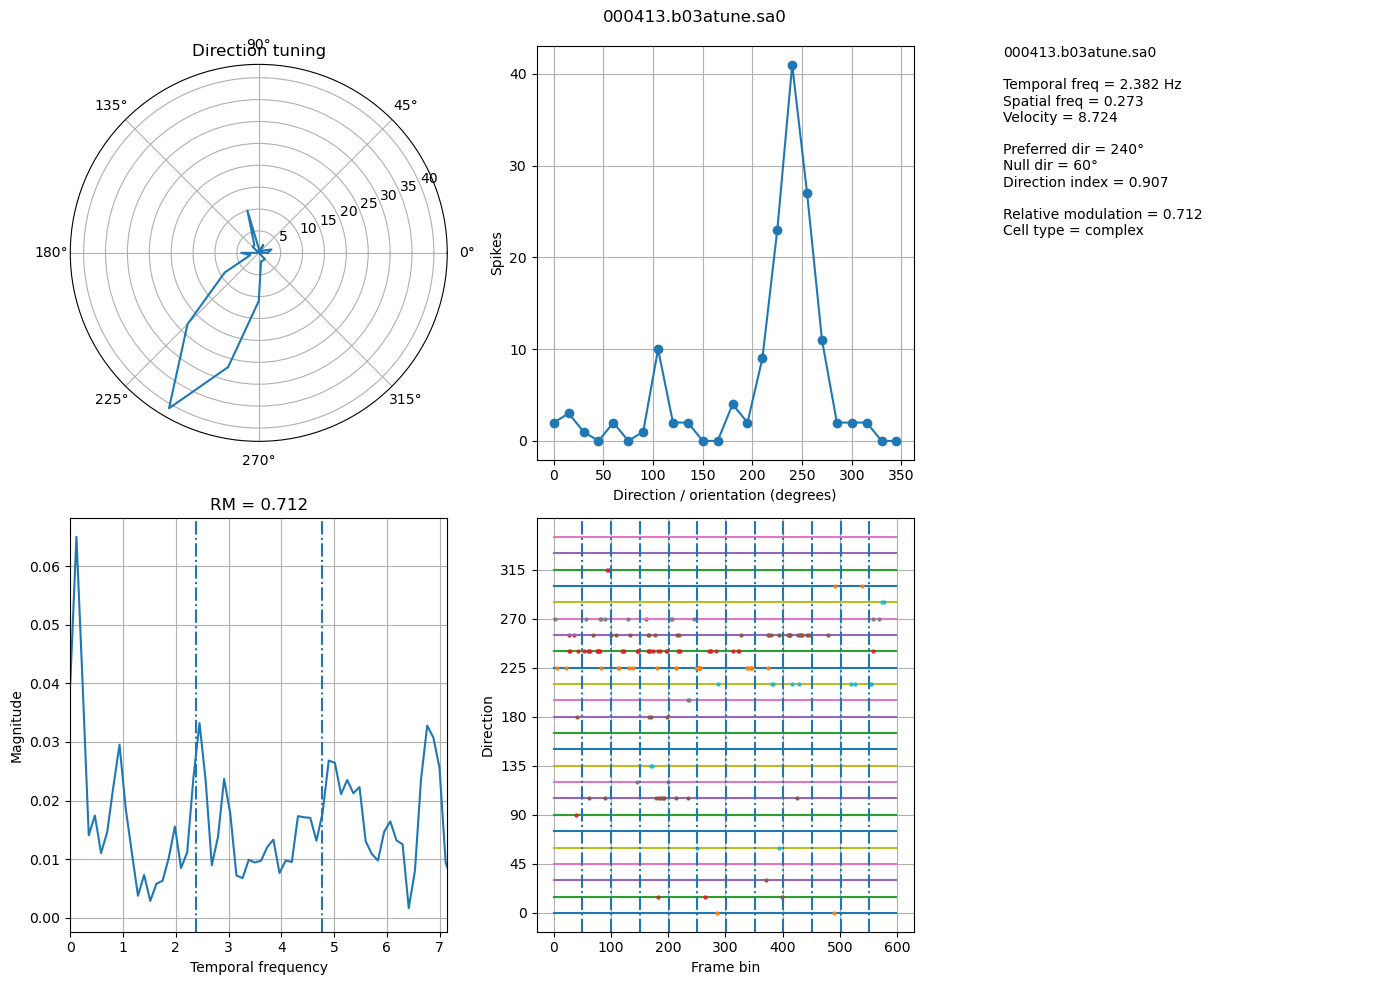

In [5]:
flog = retrieve_log(
    path=COMPLEX_NEURON_PATH,
    filename="000413.b03atune.log",
    channels=None
)

info = tori(flog, cluster_index=0, plot=True)




In [6]:

for path in paths_comples_trials:




    log_lines         = load_log_lines(path)
    remote_rr         = float(numbers(search_log(log_lines, 'TestInfo',  'RemoteRefreshRate', '119.44'))[0])
    frame_rate_factor = float(numbers(search_log(log_lines, 'TestInfo',  'FrameRateFactor',   '2'))[0])
    sti_w             = float(numbers(search_log(log_lines, 'Stimulus',  'StiW',              '9.0'))[0])

    frame_rate = remote_rr / frame_rate_factor    # effective stimulus update rate, ~59.72 Hz
    sti_w_deg  = sti_w * 0.5                      # cm → degrees (1 cm ≈ 0.5° at 114 cm viewing)


    
    print(f'Effective frame rate: {frame_rate:.4f} Hz')
    print(f'Stimulus width: {sti_w} cm = {sti_w_deg:.2f}°  ({sti_w_deg / 16:.3f}°/bar)')

Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)


### neuron b02 of 2004

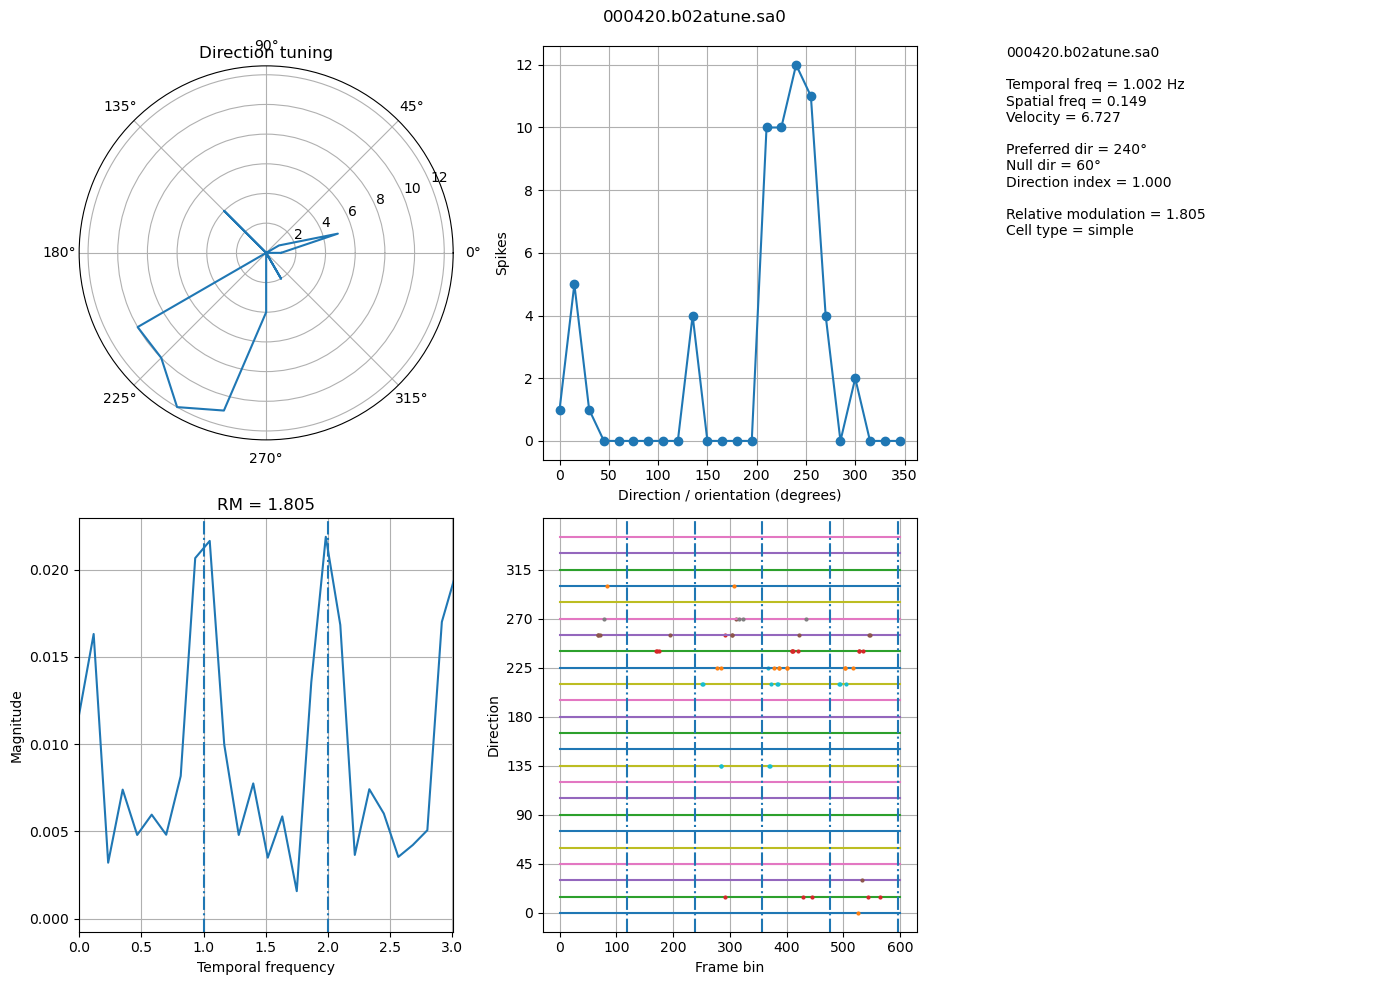

In [7]:
flog = retrieve_log(
    path=LINEAR_NEURON_PATH,
    filename="000420.b02atune.log",
    channels=None
)

info = tori(flog, cluster_index=0, plot=True)
paths = [LINEAR_NEURON_PATH / name for name in filenames_complex]


msq1D_stim = loadmat(STIM_PATH)['msq1D'].astype(float)   # (32767, 16), values ±1




In [8]:
for path in paths_linear_trial:


    msq1D_stim = loadmat(STIM_PATH)['msq1D'].astype(float)   # (32767, 16), values ±1


    log_lines         = load_log_lines( path)
    remote_rr         = float(numbers(search_log(log_lines, 'TestInfo',  'RemoteRefreshRate', '119.44'))[0])
    frame_rate_factor = float(numbers(search_log(log_lines, 'TestInfo',  'FrameRateFactor',   '2'))[0])
    sti_w             = float(numbers(search_log(log_lines, 'Stimulus',  'StiW',              '9.0'))[0])

    frame_rate = remote_rr / frame_rate_factor    # effective stimulus update rate, ~59.72 Hz
    sti_w_deg  = sti_w * 0.5                      # cm → degrees (1 cm ≈ 0.5° at 114 cm viewing)


    
    print(f'Effective frame rate: {frame_rate:.4f} Hz')
    print(f'Stimulus width: {sti_w} cm = {sti_w_deg:.2f}°  ({sti_w_deg / 16:.3f}°/bar)')

Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)


## analysis

- Each column in the left image contains the 16 bars shown at one instant in time, that is, at one stimulus frame. Since the frame rate is approximately 59.72 Hz, each frame lasts about 1/59.72≈0.0167 s, or 16.7 ms. 

- in the right image we can see the stimulus value for one frame 

- the bars are oriented in the preferred direction of the neuron found through the tuning curve

- the value of the bars is -1(dark), +1(bright)



stimulus shape:(32767, 16), stimulus mean=3.051850947599719e-05, stimulus varianc=0.9999999990686206


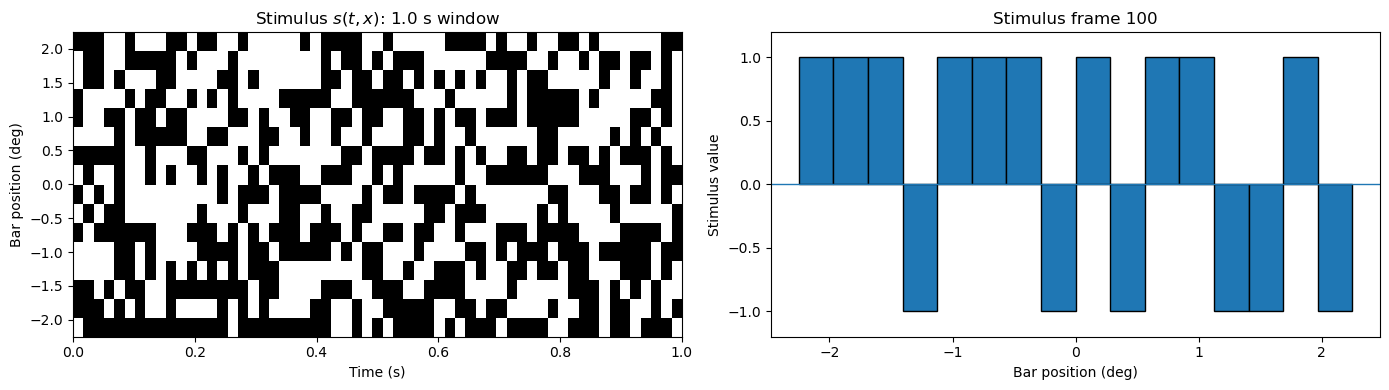

In [9]:
msq1D_stim = loadmat(STIM_PATH)['msq1D'].astype(float)   # (32767, 16), values ±1
T, N = msq1D_stim.shape
mean_stim=msq1D_stim.mean()
stimulus_variance=np.var(msq1D_stim)

print(f'stimulus shape:{T,N}, stimulus mean={mean_stim}, stimulus varianc={stimulus_variance}')

T, N = msq1D_stim.shape

width_deg = 4.50
bar_width_deg = width_deg / N

bar_centers = (
    -width_deg / 2
    + bar_width_deg / 2
    + np.arange(N) * bar_width_deg
)


t0 = 0.0
duration = 1.0

i0 = int(t0 * frame_rate)
i1 = int((t0 + duration) * frame_rate)

stim_window = msq1D_stim[i0:i1]

# ---- right plot: one single frame ----
frame = 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot 1: stimulus over time
im = axes[0].imshow(
    stim_window.T,
    aspect="auto",
    cmap="gray",
    interpolation="nearest",
    vmin=-1,
    vmax=1,
    extent=[
        t0,
        t0 + duration,
        -width_deg / 2,
        width_deg / 2,
    ],
    origin="lower"
)

axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Bar position (deg)")
axes[0].set_title(f"Stimulus $s(t,x)$: {duration:.1f} s window")

axes[1].bar(
    bar_centers,
    msq1D_stim[frame],
    width=bar_width_deg,
    align="center",
    edgecolor="black"
)

axes[1].axhline(0, linewidth=1)
axes[1].set_xlabel("Bar position (deg)")
axes[1].set_ylabel("Stimulus value")
axes[1].set_title(f"Stimulus frame {frame}")
axes[1].set_ylim(-1.2, 1.2)


plt.tight_layout()
plt.show()



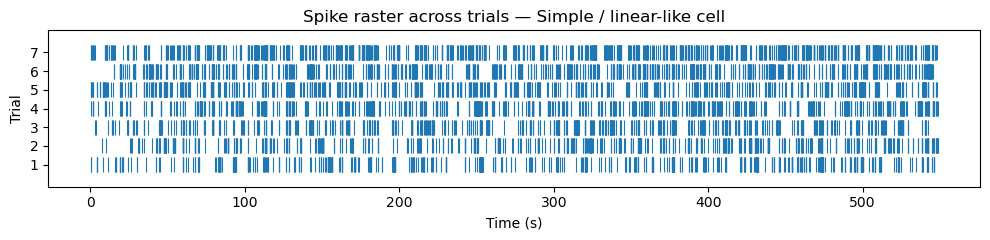

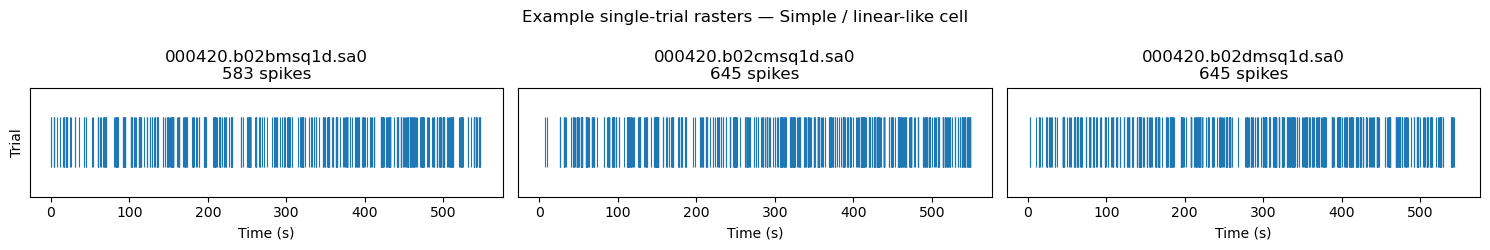

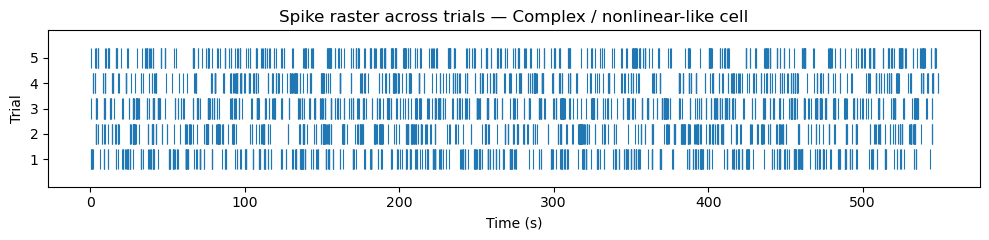

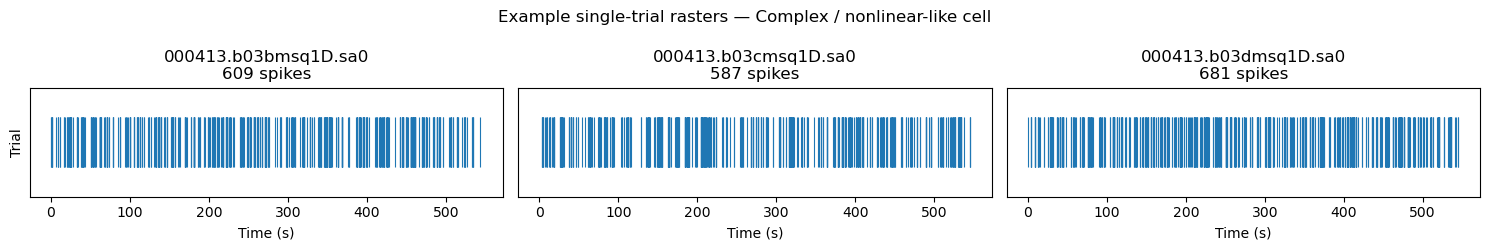

In [10]:
groups = {
    "Simple / linear-like cell": paths_linear_trial,
    "Complex / nonlinear-like cell": paths_comples_trials,
}

for group_name, paths in groups.items():

    # ---------- Full raster across all trials ----------
    plt.figure(figsize=(10, 2.5))

    for i, path in enumerate(paths):
        events, spk_sec, hdr = fget_spk_python(path)

        plt.eventplot(
            spk_sec,
            lineoffsets=i + 1,
            linelengths=0.8,
            linewidths=0.8
        )

    plt.xlabel("Time (s)")
    plt.ylabel("Trial")
    plt.yticks(range(1, len(paths) + 1))
    plt.title(f"Spike raster across trials — {group_name}")
    plt.tight_layout()
    plt.show()


    # ---------- First 3 trials next to each other ----------
    n_trials = min(3, len(paths))

    fig, axes = plt.subplots(
        1,
        n_trials,
        figsize=(5 * n_trials, 2.5),
        sharex=True,
        sharey=True
    )

    if n_trials == 1:
        axes = [axes]

    for ax, path in zip(axes, paths[:n_trials]):
        events, spike_times_sec, hdr = fget_spk_python(path)

        ax.eventplot(
            spike_times_sec,
            lineoffsets=1,
            linelengths=0.8,
            linewidths=0.8
        )

        ax.set_title(f"{Path(path).name}\n{len(events)} spikes")
        ax.set_xlabel("Time (s)")
        ax.set_yticks([])

    axes[0].set_ylabel("Trial")

    fig.suptitle(f"Example single-trial rasters — {group_name}")
    plt.tight_layout()
    plt.show()

### Spike-Triggered Average (STA)

The spike-triggered average for visual stimuli is defined as the average over trials of stimuli evaluated at times $t_i − τ$ where $t_i$ for
$i = 1,2,...,n$ are the spike times.



To choose the lag window $\tau$, we first computed the STA using a relatively large number of lags. Then, for each lag, we summarized the strength of the STA across the 16 spatial bars by computing its energy:

$E(\tau) =
\sqrt{
\sum_x \mathrm{STA}(\tau, x)^2
}$

then we plotted the sta computed at different lags to visually inspect the structure 

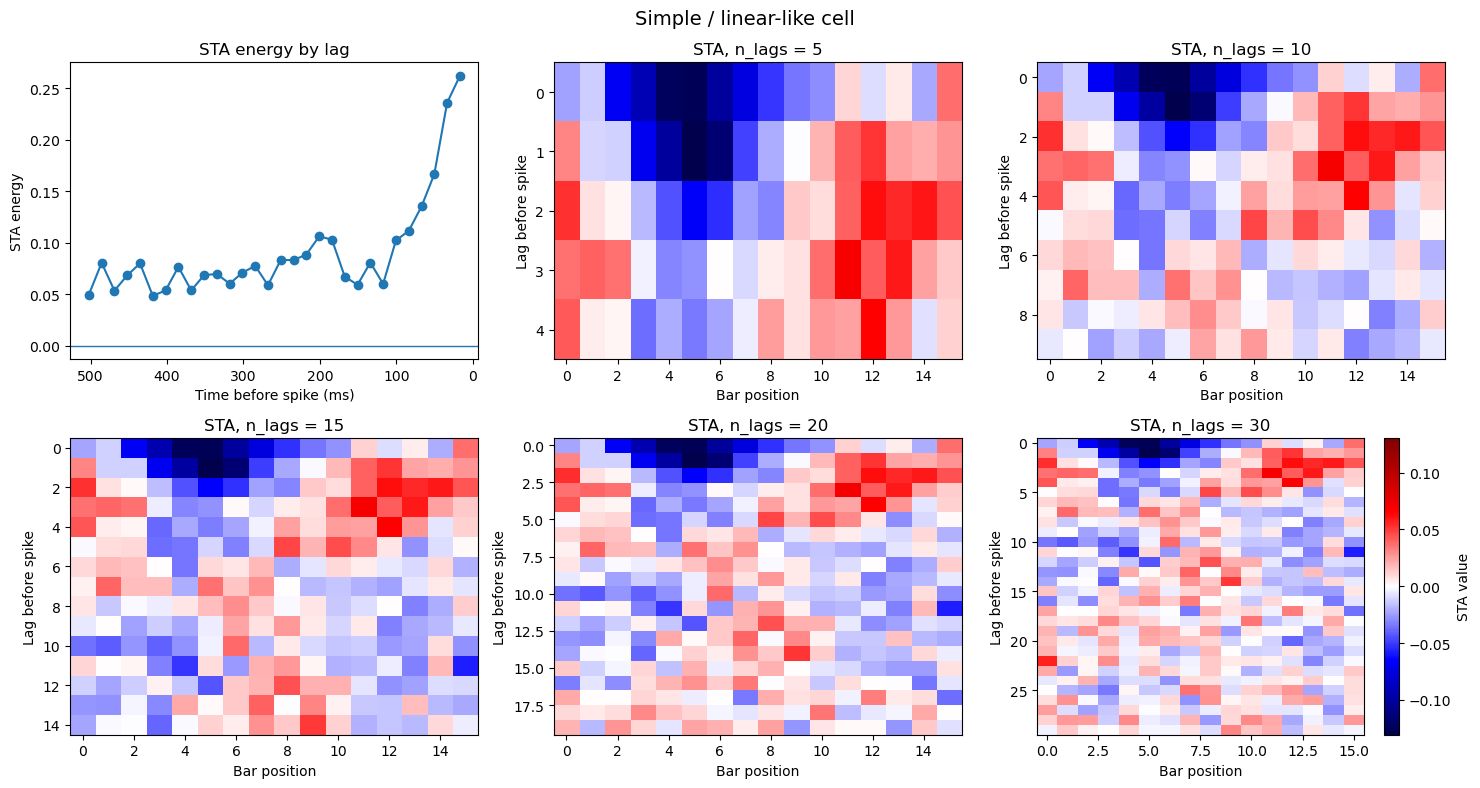

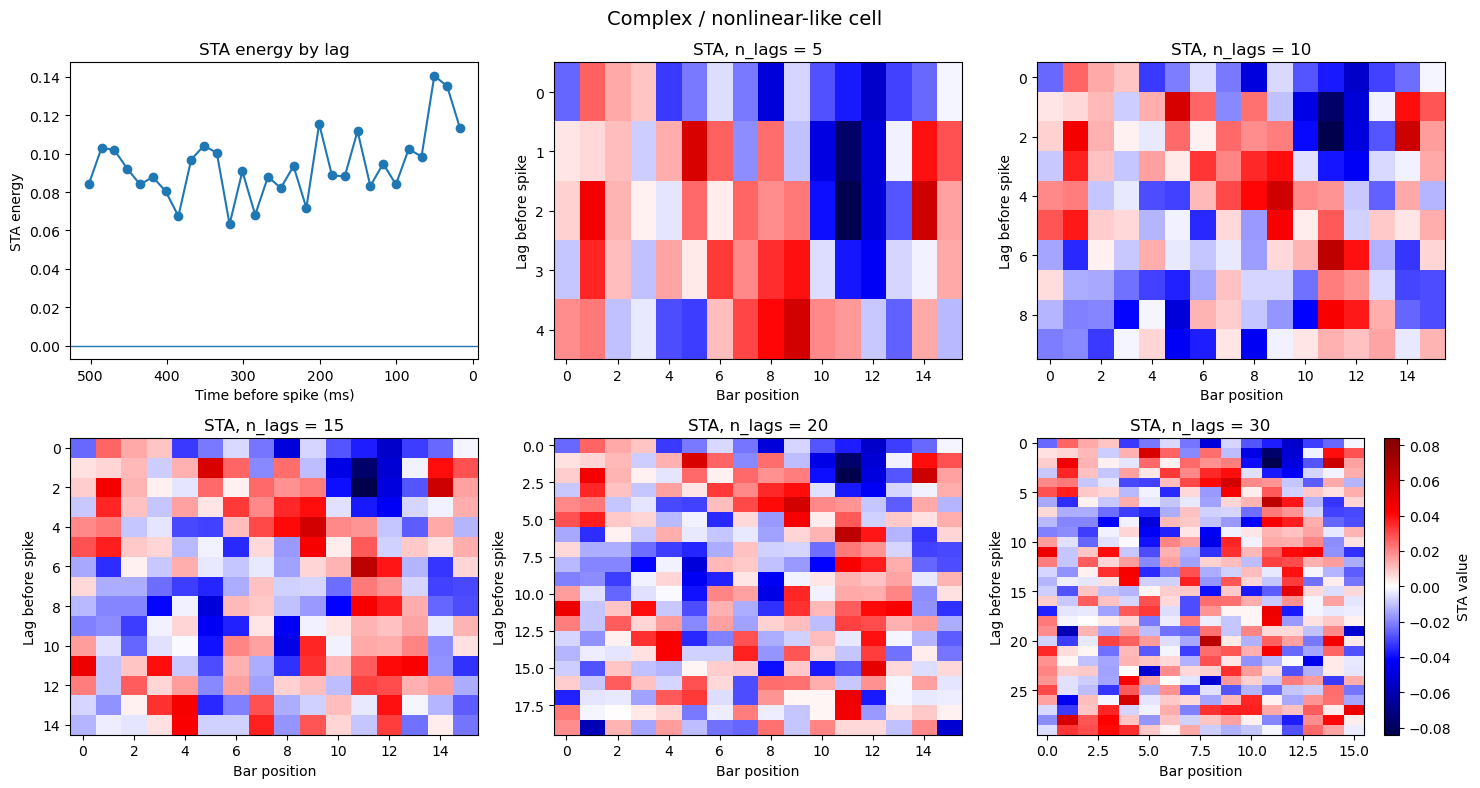

In [11]:
groups = {
    "Simple / linear-like cell": paths_linear_trial,
    "Complex / nonlinear-like cell": paths_comples_trials,
}

lag_values = [5, 10, 15, 20, 30]

all_stas = {}

for group_name, paths in groups.items():

    stas = {}

    # ---------- Compute STAs ----------
    for L in lag_values:
        sta_L, n_spikes = compute_sta(
            paths,
            msq1D_stim,
            n_lags=L,
            frame_rate=frame_rate
        )
        stas[L] = sta_L

    all_stas[group_name] = stas



    ############################################### plotting
    fig, axes = plt.subplots(
        2, 3,
        figsize=(15, 8),
        sharex=False
    )

    axes = axes.ravel()

    fig.suptitle(group_name, fontsize=14)

    # ---------- First panel: STA energy ----------
    sta_30 = stas[30]

    lag_ms = 1000 * np.arange(1, sta_30.shape[0] + 1) / frame_rate
    lag_energy = np.sqrt(np.sum(sta_30**2, axis=1))

    axes[0].plot(lag_ms, lag_energy, marker="o")
    axes[0].invert_xaxis()
    axes[0].axhline(0, linewidth=1)
    axes[0].set_title("STA energy by lag")
    axes[0].set_xlabel("Time before spike (ms)")
    axes[0].set_ylabel("STA energy")

    # ---------- Remaining five panels: STA heatmaps ----------
    vmax = max(np.max(np.abs(stas[L])) for L in lag_values)

    for ax, L in zip(axes[1:], lag_values):
        sta_L = stas[L]

        im = ax.imshow(
            sta_L,
            aspect="auto",
            cmap="seismic",
            vmin=-vmax,
            vmax=vmax,
            origin="upper"
        )

        ax.set_title(f"STA, n_lags = {L}")
        ax.set_xlabel("Bar position")
        ax.set_ylabel("Lag before spike")

    cbar = fig.colorbar(
        im,
        
    )
    cbar.set_label("STA value")

    plt.tight_layout()
    plt.show()

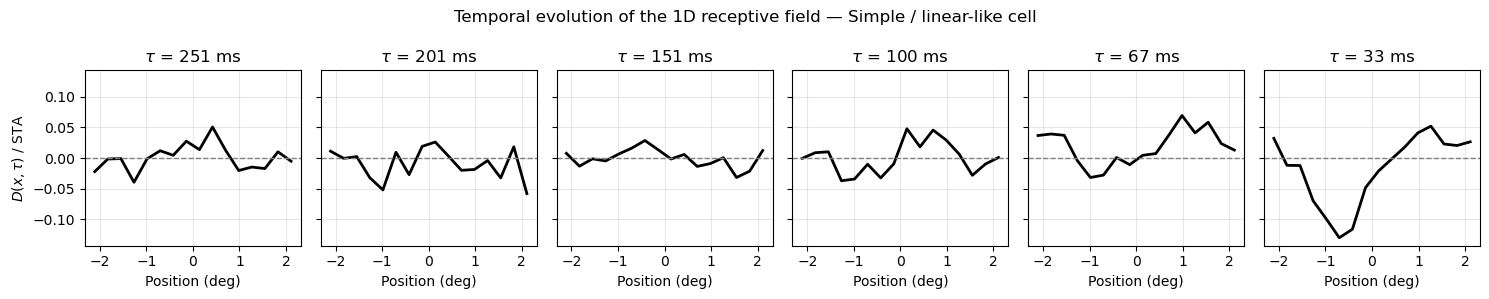

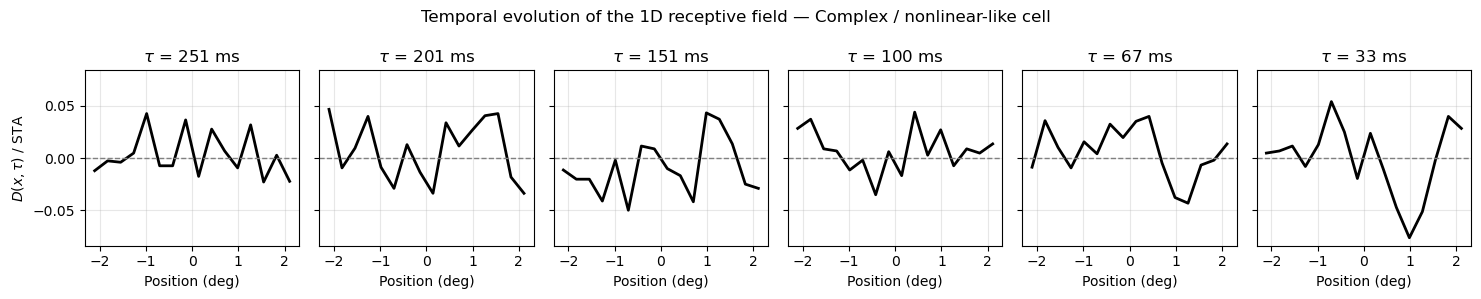

In [12]:
target_lags_ms = [250, 200, 150, 100, 75, 30]

groups_to_plot = [
    "Simple / linear-like cell",
    "Complex / nonlinear-like cell",
]

for group_name in groups_to_plot:

    sta_plot = all_stas[group_name][30]   # use the 30-lag STA

    n_lags, n_bars = sta_plot.shape

    lags_ms = 1000 * np.arange(1, n_lags + 1) / frame_rate

    lag_indices = [
        int(np.argmin(np.abs(lags_ms - target)))
        for target in target_lags_ms
    ]

    vmax = np.max(np.abs(sta_plot[lag_indices, :]))

    fig, axes = plt.subplots(
        1,
        len(lag_indices),
        figsize=(15, 3),
        sharey=True
    )

    for ax, lag_idx, target in zip(axes, lag_indices, target_lags_ms):
        profile = sta_plot[lag_idx, :]

        ax.plot(
            bar_centers,
            profile,
            color="black",
            linewidth=2
        )

        ax.axhline(
            0,
            color="gray",
            linestyle="--",
            linewidth=1
        )

        ax.set_ylim(-vmax * 1.1, vmax * 1.1)
        ax.set_title(rf"$\tau$ = {lags_ms[lag_idx]:.0f} ms")
        ax.set_xlabel("Position (deg)")
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel(r"$D(x,\tau)$ / STA")

    fig.suptitle(f"Temporal evolution of the 1D receptive field — {group_name}")
    plt.tight_layout()
    plt.show()

using $10$ lags corresponds to approximately:


$10 \times 16.7 \approx 167 \text{ ms}$

of stimulus history before the spike. Based on the STA energy plot, this window captures the main part of the response while avoiding unnecessarily long, noisier lag windows.

#### Linearity sanity check of the STA filter
we applied the learned STA kernel to the original M-sequence segment and to its contrast-inverted version. The two predicted responses were perfectly anticorrelated, r=−1, as expected for a linear filter under contrast inversion.

In [13]:
imsq1D = loadmat(ISTIM_PATH)["imsq1D"].astype(float)

print(np.all(imsq1D == -msq1D_stim[:512]))
print(np.mean(imsq1D + msq1D_stim[:512]))

True
0.0


In [14]:
r_inv = compute_r_estimate(imsq1D, stas[10])
r_orig_512 = compute_r_estimate(msq1D_stim[:512], stas[10])

valid = np.isfinite(r_inv) & np.isfinite(r_orig_512)

print(np.corrcoef(r_inv[valid], r_orig_512[valid])[0, 1])

-0.9999999999999999


### Optimal Kernel Estimation

The theoretical relation between the optimal linear kernel and the spike-triggered average is $D(\tau, x) = \frac{\langle r \rangle}{\sigma_s^2} \mathrm{STA}(\tau, x)$

The stimulus variance is $\sigma_s^2 \approx 1.$ Thus, for this stimulus, $D(\tau, x)\approx\langle r \rangle \mathrm{STA}(\tau, x).$

So the optimal kernel has the same spatiotemporal structure as the STA, but it is scaled by the mean firing rate.

In [15]:
n_spikes = 0

for path in paths_linear_trial:
    events, spk_sec, hdr = fget_spk_python(path)
    n_spikes += len(events)

print("Total spikes:", n_spikes)


recording_duration = T / frame_rate * 6
mean_firing_rate = n_spikes / recording_duration

Total spikes: 5641


Mean correlation: 0.048326389707273855
Std correlation: 0.010991775220675858


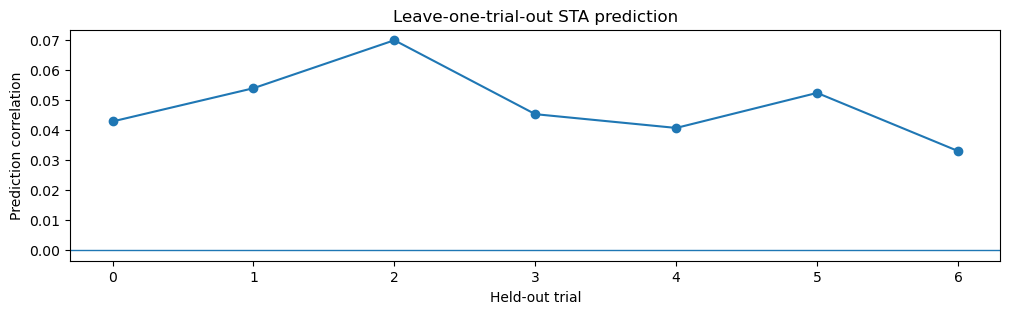

In [16]:
loo_corrs = []
loo_results=[]

for test_idx in range(len(paths_linear_trial,)):
    train_files = [f for i, f in enumerate(paths_linear_trial,) if i != test_idx]
    test_file = paths_linear_trial[test_idx]

    sta_train, n_train = compute_sta(
        train_files,
        msq1D_stim,
        n_lags=n_lags,
        frame_rate=frame_rate,
        
    )

    r_est = compute_r_estimate(msq1D_stim, sta_train, r0=mean_firing_rate)

    _, spk_sec_test, _ = fget_spk_python(test_file)

    spike_counts = bin_spikes_to_frames(
        spk_sec_test,
        T=T,
        frame_rate=frame_rate,
        
    )

    rate_test = smooth_frame_counts(
        spike_counts,
        frame_rate=frame_rate,
        sigma_sec=0.05
    )
    valid = np.isfinite(r_est) & np.isfinite(rate_test)
    x = r_est[valid]
    y = rate_test[valid]
    corr=np.corrcoef(x, y)[0, 1]
    
    loo_corrs.append(corr)
    
    loo_results.append({
        "test_idx": test_idx,
        "test_file": test_file,
        "r_est": r_est,
        "rate_test": rate_test,
        "spike_counts": spike_counts,
        "corr": corr,
    })

loo_corrs = np.array(loo_corrs)

print("Mean correlation:", np.nanmean(loo_corrs))
print("Std correlation:", np.nanstd(loo_corrs))


plt.figure(figsize=(12, 3))
plt.plot(loo_corrs, marker="o")
plt.axhline(0, linewidth=1)
plt.xlabel("Held-out trial")
plt.ylabel("Prediction correlation")
plt.title("Leave-one-trial-out STA prediction")
plt.show()


To visualize the relationship between the STA prediction and the held-out neural response, we binned time points according to the z-scored STA prediction and computed the mean observed firing rate within each bin. The observed response increases monotonically with the STA prediction, indicating that time points with stronger predicted linear drive tend to have higher firing rates. Although the frame-wise correlation is small (\(r = 0.070\)), the binned curve shows a clear positive relationship between the STA-based prediction and the held-out response.

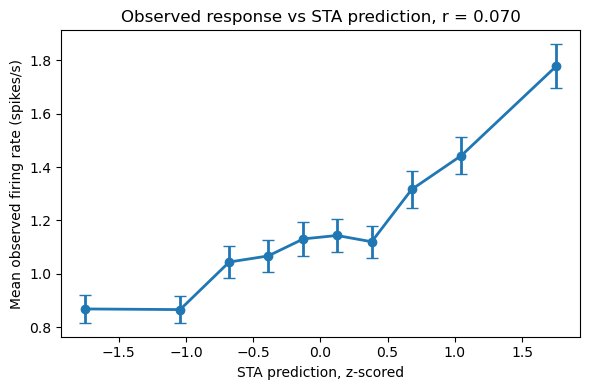

In [17]:
trial_to_plot = 2

res = loo_results[trial_to_plot]

r_est = res["r_est"]
rate_test = res["rate_test"]
corr = res["corr"]

valid = np.isfinite(r_est) & np.isfinite(rate_test)

x = r_est[valid]
y = rate_test[valid]

# z-score prediction for binning
x_z = (x - np.mean(x)) / np.std(x)

n_bins = 10
bins = np.quantile(x_z, np.linspace(0, 1, n_bins + 1))

bin_centers = []
mean_response = []
sem_response = []

for i in range(n_bins):
    in_bin = (x_z >= bins[i]) & (x_z <= bins[i + 1])

    bin_centers.append(np.mean(x_z[in_bin]))
    mean_response.append(np.mean(y[in_bin]))
    sem_response.append(np.std(y[in_bin]) / np.sqrt(np.sum(in_bin)))

bin_centers = np.array(bin_centers)
mean_response = np.array(mean_response)
sem_response = np.array(sem_response)

plt.figure(figsize=(6, 4))

plt.errorbar(
    bin_centers,
    mean_response,
    yerr=sem_response,
    marker="o",
    capsize=4,
    linewidth=2
)

plt.xlabel("STA prediction, z-scored")
plt.ylabel("Mean observed firing rate (spikes/s)")
plt.title(f"Observed response vs STA prediction, r = {corr:.3f}")

plt.tight_layout()
plt.show()

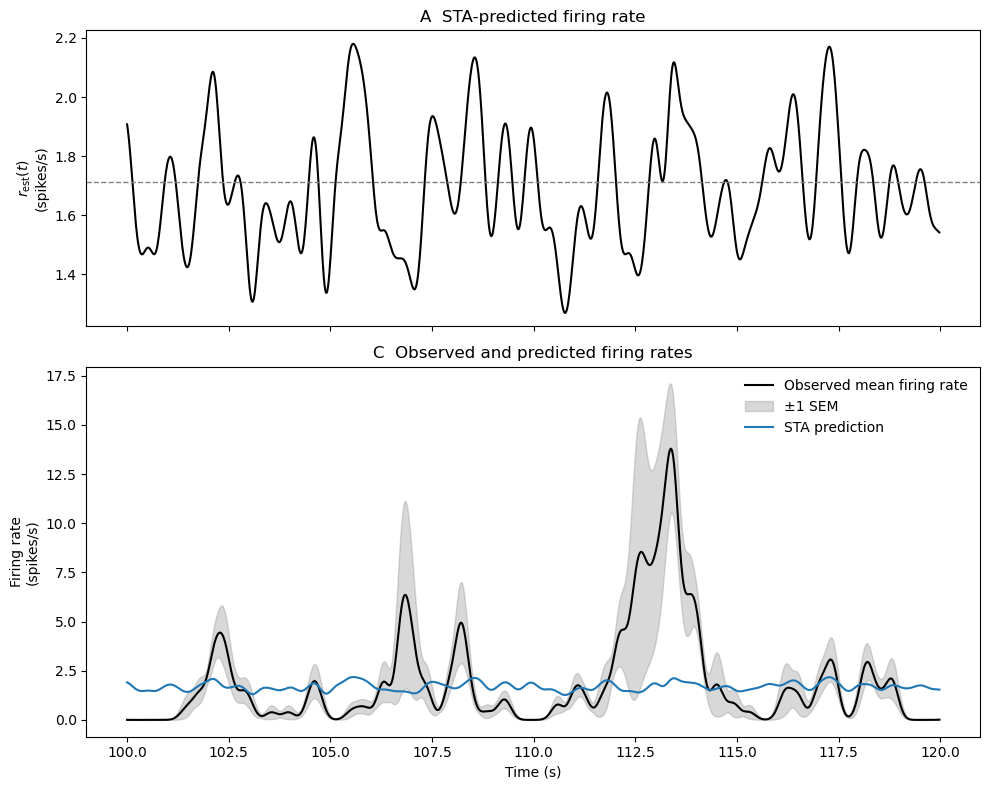

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d



t0 = 100       # seconds
duration = 20 # seconds

i0 = int(t0 * frame_rate)
i1 = int((t0 + duration) * frame_rate)

t = np.arange(T) / frame_rate

sta_10=all_stas['Simple / linear-like cell'][10]


# mean_firing_rate should already be computed, e.g. 1.71 spikes/s
kernel = mean_firing_rate * sta_10 / stimulus_variance

r_est = compute_r_estimate(
    msq1D_stim,
    kernel,
    r0=mean_firing_rate
)

# Optional: linear model can go negative, so for a rate plot you may rectify
r_est_plot = np.maximum(r_est, 0)


# ============================================================
# Build observed response across trials
# ============================================================

trial_counts = []

for path in paths_linear_trial:
    events, spk_sec, hdr = fget_spk_python(path)

    counts = bin_spikes_to_frames(
        spk_sec,
        T=T,
        frame_rate=frame_rate,
        stim_onset_sec=0.0
    )

    trial_counts.append(counts)

trial_counts = np.array(trial_counts)

sigma_sec = 0.15  # use 150 ms smoothing for visualization

trial_rates = np.array([
    gaussian_filter1d(
        counts.astype(float),
        sigma=sigma_sec * frame_rate,
        mode="constant"
    ) * frame_rate
    for counts in trial_counts
])

mean_rate = trial_rates.mean(axis=0)
sem_rate = trial_rates.std(axis=0) / np.sqrt(trial_rates.shape[0])


# ============================================================
# Smooth predicted rate for visual comparison
# ============================================================

r_est_smooth = gaussian_filter1d(
    r_est_plot.astype(float),
    sigma=sigma_sec * frame_rate,
    mode="constant"
)


# ============================================================
# Make figure like the textbook
# ============================================================

fig, axes = plt.subplots(
    2, 1,
    figsize=(10, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [1.2, 1.5]}
)

# ------------------------------------------------------------
# A: STA-predicted response
# ------------------------------------------------------------

ax = axes[0]

ax.plot(
    t[i0:i1],
    r_est_smooth[i0:i1],
    color="black",
    linewidth=1.5
)

ax.set_ylabel(r"$r_{\mathrm{est}}(t)$" "\n(spikes/s)")
ax.set_title("A  STA-predicted firing rate")
ax.axhline(mean_firing_rate, color="gray", linestyle="--", linewidth=1)

# ------------------------------------------------------------
# B: spike raster across trials
# ------------------------------------------------------------

# ------------------------------------------------------------
# C: observed vs predicted firing rate
# ------------------------------------------------------------

ax = axes[1]

ax.plot(
    t[i0:i1],
    mean_rate[i0:i1],
    color="black",
    linewidth=1.5,
    label="Observed mean firing rate"
)

ax.fill_between(
    t[i0:i1],
    mean_rate[i0:i1] - sem_rate[i0:i1],
    mean_rate[i0:i1] + sem_rate[i0:i1],
    color="gray",
    alpha=0.3,
    label="±1 SEM"
)

ax.plot(
    t[i0:i1],
    r_est_smooth[i0:i1],
    color="tab:blue",
    linewidth=1.5,
    label="STA prediction"
)

ax.set_ylabel("Firing rate\n(spikes/s)")
ax.set_xlabel("Time (s)")
ax.set_title("C  Observed and predicted firing rates")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

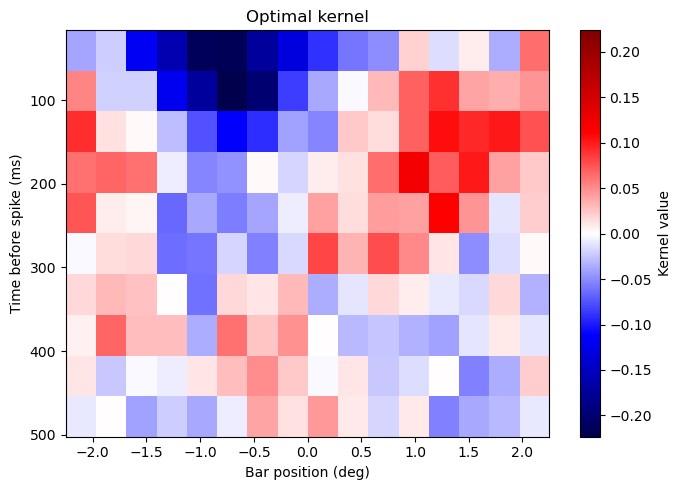

In [21]:
plt.figure(figsize=(7, 5))

vmax = np.max(np.abs(kernel))

plt.imshow(
    kernel,
    aspect="auto",
    cmap="seismic",
    interpolation="nearest",
    vmin=-vmax,
    vmax=vmax,
    extent=[
        -width_deg / 2,
        width_deg / 2,
        lag_ms[-1],
        lag_ms[0],
    ],
    origin="upper"
)

plt.xlabel("Bar position (deg)")
plt.ylabel("Time before spike (ms)")
plt.title("Optimal kernel")
plt.colorbar(label="Kernel value")
plt.tight_layout()
plt.show()